In [ ]:
#Preparación de los datos

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [ ]:
#Preprocesamiento

# Aplanar las imágenes de 28x28 a 784
x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)

# Normalizar los valores de los píxeles entre 0 y 1
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

# Convertir las etiquetas a codificación one-hot
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(60000, 784)
(10000, 784)
(60000, 10)
(10000, 10)


In [ ]:
#Busqueda de Red Base
# (Usaremos accuracy de validación como criterio para elegir la mejor red)

from tensorflow.keras.optimizers import Adam, RMSprop, SGD

In [ ]:
# Instalar Optuna
!pip -q install optuna

# Importaciones
import optuna
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.losses import CategoricalCrossentropy

print("Optuna:", optuna.__version__)
print("TensorFlow:", tf.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 15.8 MB/s eta 0:00:00
Optuna: 5.0.0
TensorFlow: 2.20.0


In [ ]:
def crear_modelo(trial):

    # Número de capas ocultas
    n_layers = trial.suggest_int("n_layers", 1, 4)

    # Función de activación
    activation = trial.suggest_categorical(
        "activation",
        ["relu", "tanh", "sigmoid"]
    )

    # Crear modelo secuencial
    model = Sequential()

    # Capa de entrada
    model.add(Input(shape=(784,)))

    # Capas ocultas
    for i in range(n_layers):

        units = trial.suggest_int(
            f"units_layer_{i+1}",
            64,
            512,
            step=64
        )

        model.add(
            Dense(
                units=units,
                activation=activation
            )
        )

    # Capa de salida
    model.add(
        Dense(
            10,
            activation="softmax"
        )
    )

    # Optimización
    optimizer_name = trial.suggest_categorical(
        "optimizer",
        ["Adam", "RMSprop", "SGD"]
    )

    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-4,
        1e-2,
        log=True
    )

    if optimizer_name == "Adam":
        optimizer = Adam(learning_rate=learning_rate)
    elif optimizer_name == "RMSprop":
        optimizer = RMSprop(learning_rate=learning_rate)
    else:
        optimizer = SGD(learning_rate=learning_rate)

    # Compilar
    model.compile(
        loss=CategoricalCrossentropy(from_logits=False),
        optimizer=optimizer,
        metrics=["accuracy"]
    )

    return model

In [ ]:
def objective(trial):

    # Crear una arquitectura nueva
    model = crear_modelo(trial)

    # Tamaño del batch
    batch_size = trial.suggest_categorical(
        "batch_size",
        [64, 128, 256]
    )

    # Entrenamiento
    history = model.fit(
        x_train,
        y_train,
        validation_split=0.1,
        epochs=10,
        batch_size=batch_size,
        verbose=0
    )

    # Mejor accuracy de validación alcanzada
    best_val_accuracy = max(
        history.history["val_accuracy"]
    )

    # Liberar memoria
    tf.keras.backend.clear_session()

    return best_val_accuracy

In [ ]:
# Crear estudio de Optuna
study = optuna.create_study(
    direction="maximize",
    study_name="MNIST_Dense_Network"
)

# Ejecutar experimentos
study.optimize(
    objective,
    n_trials=20
)

print("\nMejor resultado:")
print("Accuracy de validación:", study.best_value)

print("\nMejores hiperparámetros:")
for parametro, valor in study.best_params.items():
    print(f"{parametro}: {valor}")

[I 2026-09-14 20:40:46,070] A new study created in memory with name: MNIST_Dense_Network
[I 2026-09-14 20:41:13,790] Trial 0 finished with value: 0.1901666671037674 and parameters: {'n_layers': 2, 'activation': 'sigmoid', 'units_layer_1': 128, 'units_layer_2': 192, 'optimizer': 'SGD', 'learning_rate': 0.0007079774096975967, 'batch_size': 128}. Best is trial 0 with value: 0.1901666671037674.
[I 2026-09-14 20:42:42,925] Trial 1 finished with value: 0.9756666421890259 and parameters: {'n_layers': 3, 'activation': 'tanh', 'units_layer_1': 320, 'units_layer_2': 320, 'units_layer_3': 320, 'optimizer': 'Adam', 'learning_rate': 0.0026497331534992173, 'batch_size': 64}. Best is trial 1 with value: 0.9756666421890259.
[I 2026-09-14 20:43:29,277] Trial 2 finished with value: 0.9794999957084656 and parameters: {'n_layers': 3, 'activation': 'tanh', 'units_layer_1': 320, 'units_layer_2': 256, 'units_layer_3': 512, 'optimizer': 'RMSprop', 'learning_rate': 0.0006838360551490866, 'batch_size': 256}. Be


Mejor resultado:
Accuracy de validación: 0.984333336353302

Mejores hiperparámetros:
n_layers: 3
activation: relu
units_layer_1: 448
units_layer_2: 384
units_layer_3: 192
optimizer: RMSprop
learning_rate: 0.0011786145402438867
batch_size: 64


In [ ]:
# Guardar resultados

# Mostrar un resumen de todos los experimentos
print(f"Número de experimentos realizados: {len(study.trials)}")

print("\nMejor trial:")
print(f"Trial: {study.best_trial.number}")
print(f"Accuracy de validación: {study.best_value:.4f}")

print("\nHiperparámetros:")
for parametro, valor in study.best_params.items():
    print(f"{parametro}: {valor}")

Número de experimentos realizados: 20

Mejor trial:
Trial: 15
Accuracy de validación: 0.9843

Hiperparámetros:
n_layers: 3
activation: relu
units_layer_1: 448
units_layer_2: 384
units_layer_3: 192
optimizer: RMSprop
learning_rate: 0.0011786145402438867
batch_size: 64


In [ ]:
#Reconstrucción de la mejor red

# Recuperar los mejores hiperparámetros
best_params = study.best_params

# Crear nuevamente el modelo ganador
best_model = Sequential()

best_model.add(Input(shape=(784,)))

best_model.add(
    Dense(
        best_params["units_layer_1"],
        activation=best_params["activation"]
    )
)

best_model.add(
    Dense(
        best_params["units_layer_2"],
        activation=best_params["activation"]
    )
)

best_model.add(
    Dense(
        best_params["units_layer_3"],
        activation=best_params["activation"]
    )
)

best_model.add(
    Dense(
        10,
        activation="softmax"
    )
)

# Crear el optimizador ganador
if best_params["optimizer"] == "Adam":
    optimizer = Adam(
        learning_rate=best_params["learning_rate"]
    )
elif best_params["optimizer"] == "RMSprop":
    optimizer = RMSprop(
        learning_rate=best_params["learning_rate"]
    )
else:
    optimizer = SGD(
        learning_rate=best_params["learning_rate"]
    )

# Compilar
best_model.compile(
    loss=CategoricalCrossentropy(from_logits=False),
    optimizer=optimizer,
    metrics=["accuracy"]
)

# Mostrar arquitectura
best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 448)            │       351,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 384)            │       172,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 192)            │        73,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,930 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 599,946 (2.29 MB)

 Trainable params: 599,946 (2.29 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Entrenamiento de la mejor arquitectura
history_best = best_model.fit(
    x_train,
    y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=best_params["batch_size"],
    verbose=1
)

Epoch 1/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9304 - loss: 0.2269 - val_accuracy: 0.9665 - val_loss: 0.1061
Epoch 2/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9719 - loss: 0.0944 - val_accuracy: 0.9748 - val_loss: 0.0847
Epoch 3/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9800 - loss: 0.0651 - val_accuracy: 0.9803 - val_loss: 0.0754
Epoch 4/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9849 - loss: 0.0504 - val_accuracy: 0.9802 - val_loss: 0.0882
Epoch 5/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9889 - loss: 0.0384 - val_accuracy: 0.9807 - val_loss: 0.0836
Epoch 6/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9913 - loss: 0.0308 - val_accuracy: 0.9787 - val_loss: 0.1216
Epoch 7/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9926 - loss: 0.0269 - val_accuracy: 0.9787 - val_loss: 0.0906
Epoch 8/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9935 - loss: 0.0228 - va

In [ ]:
# Evaluación final en datos de prueba
test_loss, test_accuracy = best_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print(f"Loss en test: {test_loss:.4f}")
print(f"Accuracy en test: {test_accuracy:.4f}")

Loss en test: 0.1564
Accuracy en test: 0.9848


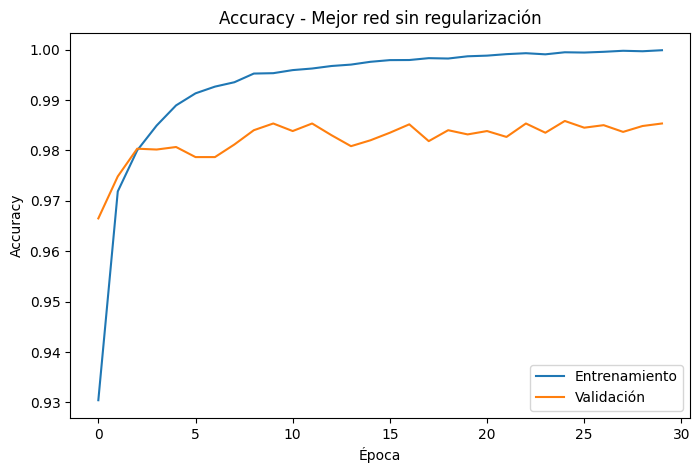

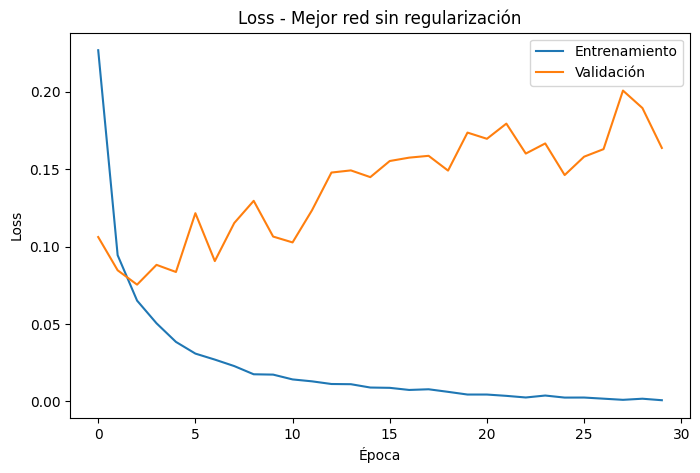

In [ ]:
import matplotlib.pyplot as plt

# Curva de accuracy
plt.figure(figsize=(8, 5))
plt.plot(history_best.history["accuracy"], label="Entrenamiento")
plt.plot(history_best.history["val_accuracy"], label="Validación")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("Accuracy - Mejor red sin regularización")
plt.legend()
plt.show()

# Curva de pérdida
plt.figure(figsize=(8, 5))
plt.plot(history_best.history["loss"], label="Entrenamiento")
plt.plot(history_best.history["val_loss"], label="Validación")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Loss - Mejor red sin regularización")
plt.legend()
plt.show()

In [ ]:
# Regularización

from tensorflow.keras import regularizers
from tensorflow.keras.layers import Dropout


def crear_modelo_regularizado(tipo):

    model = Sequential()

    model.add(Input(shape=(784,)))

    # Configuración de regularización
    if tipo == "L1":
        regularizer = regularizers.l1(0.0001)
        dropout_rate = None

    elif tipo == "L2":
        regularizer = regularizers.l2(0.0001)
        dropout_rate = None

    elif tipo == "L1_L2":
        regularizer = regularizers.l1_l2(
            l1=0.0001,
            l2=0.0001
        )
        dropout_rate = None

    elif tipo == "Dropout":
        regularizer = None
        dropout_rate = 0.3

    elif tipo == "Dropout_L1_L2":
        regularizer = regularizers.l1_l2(
            l1=0.0001,
            l2=0.0001
        )
        dropout_rate = 0.3

    # Primera capa
    model.add(
        Dense(
            448,
            activation="relu",
            kernel_regularizer=regularizer
        )
    )

    if dropout_rate is not None:
        model.add(Dropout(dropout_rate))

    # Segunda capa
    model.add(
        Dense(
            384,
            activation="relu",
            kernel_regularizer=regularizer
        )
    )

    if dropout_rate is not None:
        model.add(Dropout(dropout_rate))

    # Tercera capa
    model.add(
        Dense(
            192,
            activation="relu",
            kernel_regularizer=regularizer
        )
    )

    if dropout_rate is not None:
        model.add(Dropout(dropout_rate))

    # Salida
    model.add(
        Dense(
            10,
            activation="softmax"
        )
    )

    # Compilar
    optimizer = RMSprop(
        learning_rate=0.0011786145402438867
    )

    model.compile(
        loss=CategoricalCrossentropy(from_logits=False),
        optimizer=optimizer,
        metrics=["accuracy"]
    )

    return model

In [ ]:
# Tipos de regularización
tipos_regularizacion = [
    "L1",
    "L2",
    "L1_L2",
    "Dropout",
    "Dropout_L1_L2"
]

# Diccionarios para guardar modelos e historias
modelos_reg = {}
historias_reg = {}

# Entrenar cada modelo
for tipo in tipos_regularizacion:

    print("\n" + "="*60)
    print(f"ENTRENANDO: {tipo}")
    print("="*60)

    model = crear_modelo_regularizado(tipo)

    history = model.fit(
        x_train,
        y_train,
        validation_split=0.1,
        epochs=30,
        batch_size=64,
        verbose=1
    )

    modelos_reg[tipo] = model
    historias_reg[tipo] = history

    print(f"\n{tipo} terminado.")


ENTRENANDO: L1
Epoch 1/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.9193 - loss: 1.0594 - val_accuracy: 0.9532 - val_loss: 0.4828
Epoch 2/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.9579 - loss: 0.3815 - val_accuracy: 0.9620 - val_loss: 0.3153
Epoch 3/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9665 - loss: 0.2786 - val_accuracy: 0.9722 - val_loss: 0.2436
Epoch 4/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.9696 - loss: 0.2402 - val_accuracy: 0.9753 - val_loss: 0.2116
Epoch 5/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.9719 - loss: 0.2191 - val_accuracy: 0.9765 - val_loss: 0.1990
Epoch 6/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9737 - loss: 0.2056 - val_accuracy: 0.9768 - val_loss: 0.1981
Epoch 7/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.9749 - loss: 0.1945 - val_accuracy: 0.9743 - val_loss: 0.2008
Epoch 8/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9760 -

In [ ]:
import pandas as pd

resultados = []

# Baseline
resultados.append({
    "Modelo": "Baseline",
    "Train Accuracy": history_best.history["accuracy"][-1],
    "Val Accuracy": history_best.history["val_accuracy"][-1],
    "Best Val Accuracy": max(history_best.history["val_accuracy"]),
    "Test Accuracy": best_model.evaluate(x_test, y_test, verbose=0)[1],
    "Train-Val Gap": (
        history_best.history["accuracy"][-1]
        - history_best.history["val_accuracy"][-1]
    )
})

# Modelos regularizados
for tipo, model in modelos_reg.items():

    history = historias_reg[tipo]

    test_loss, test_acc = model.evaluate(
        x_test, y_test, verbose=0
    )

    resultados.append({
        "Modelo": tipo,
        "Train Accuracy": history.history["accuracy"][-1],
        "Val Accuracy": history.history["val_accuracy"][-1],
        "Best Val Accuracy": max(history.history["val_accuracy"]),
        "Test Accuracy": test_acc,
        "Train-Val Gap": (
            history.history["accuracy"][-1]
            - history.history["val_accuracy"][-1]
        )
    })

df_resultados = pd.DataFrame(resultados)

df_resultados

,Modelo,Train Accuracy,Val Accuracy,Best Val Accuracy,Test Accuracy,Train-Val Gap
0,Baseline,0.999870,0.985333,0.985833,0.9848,0.014537
1,L1,0.981463,0.976167,0.979833,0.9726,0.005296
2,L2,0.990037,0.981000,0.983000,0.9799,0.009037
3,L1_L2,0.979778,0.977000,0.977833,0.9744,0.002778
4,Dropout,0.992019,0.984833,0.987167,0.9859,0.007185
5,Dropout_L1_L2,0.949167,0.974000,0.979000,0.9687,-0.024833


REGISTRO DE RESULTADOS

In [ ]:
REPO_NAME = "Red_Densa"
REPO_OWNER = "AilinBG"
USER_NAME = "AilinBG"

In [ ]:
!pip install mlflow --quiet

import mlflow
import os
from getpass import getpass

os.environ["MLFLOW_TRACKING_USERNAME"] = USER_NAME
os.environ["MLFLOW_TRACKING_PASSWORD"] = getpass(
    "Enter your DAGsHub access token or password: "
)

mlflow.set_tracking_uri(
    f"https://dagshub.com/{REPO_OWNER}/{REPO_NAME}.mlflow"
)

print("MLflow conectado a DagsHub")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 66.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.

In [ ]:
import mlflow

mlflow.set_experiment("MNIST_Optuna_Search")

for trial in study.trials:
    if trial.state == optuna.trial.TrialState.COMPLETE:

        with mlflow.start_run(run_name=f"Optuna_Trial_{trial.number}"):

            # Registrar parámetros
            mlflow.log_params(trial.params)

            # Registrar métrica
            mlflow.log_metric("val_accuracy", trial.value)

print("Experimentos registrados correctamente en MLflow.")

2026/09/14 23:20:42 INFO mlflow.tracking.fluent: Experiment with name 'MNIST_Optuna_Search' does not exist. Creating a new experiment.


🏃 View run Optuna_Trial_0 at: https://dagshub.com/AilinBG/Red_Densa.mlflow/#/experiments/0/runs/d0ea3018328246009fbd87ca783b0522
🧪 View experiment at: https://dagshub.com/AilinBG/Red_Densa.mlflow/#/experiments/0
🏃 View run Optuna_Trial_1 at: https://dagshub.com/AilinBG/Red_Densa.mlflow/#/experiments/0/runs/928e59640f224d80b4ce2c756cbadd3c
🧪 View experiment at: https://dagshub.com/AilinBG/Red_Densa.mlflow/#/experiments/0
🏃 View run Optuna_Trial_2 at: https://dagshub.com/AilinBG/Red_Densa.mlflow/#/experiments/0/runs/4b3b75048933432cb7621d4529d7aafb
🧪 View experiment at: https://dagshub.com/AilinBG/Red_Densa.mlflow/#/experiments/0
🏃 View run Optuna_Trial_3 at: https://dagshub.com/AilinBG/Red_Densa.mlflow/#/experiments/0/runs/417e8935b09441d0a8713e74e16c3e7e
🧪 View experiment at: https://dagshub.com/AilinBG/Red_Densa.mlflow/#/experiments/0
🏃 View run Optuna_Trial_4 at: https://dagshub.com/AilinBG/Red_Densa.mlflow/#/experiments/0/runs/bac39b7152094f34b660161c185a2ae5
🧪 View experiment at: h

In [ ]:
best_trial = study.best_trial

with mlflow.start_run(run_name="Best_Optuna_Model"):

    mlflow.log_params(best_trial.params)
    mlflow.log_metric("best_val_accuracy", best_trial.value)

print("Mejor experimento registrado.")
print("Best validation accuracy:", best_trial.value)
print("Best parameters:", best_trial.params)

🏃 View run Best_Optuna_Model at: https://dagshub.com/AilinBG/Red_Densa.mlflow/#/experiments/0/runs/ae18bfd8c193434181e26787ba41ae8d
🧪 View experiment at: https://dagshub.com/AilinBG/Red_Densa.mlflow/#/experiments/0
Mejor experimento registrado.
Best validation accuracy: 0.984333336353302
Best parameters: {'n_layers': 3, 'activation': 'relu', 'units_layer_1': 448, 'units_layer_2': 384, 'units_layer_3': 192, 'optimizer': 'RMSprop', 'learning_rate': 0.0011786145402438867, 'batch_size': 64}


In [ ]:
mlflow.set_experiment("MNIST_Regularization")

resultados_reg = {
    "Baseline": {
        "test_accuracy": 0.9847999811172485,
        "best_val_accuracy": 0.9858333468437195,
        "train_val_gap": 0.014537036418914795
    },
    "L1": {
        "test_accuracy": 0.972599983215332,
        "best_val_accuracy": 0.9798333048820496,
        "train_val_gap": 0.005296289920806885
    },
    "L2": {
        "test_accuracy": 0.9799000024795532,
        "best_val_accuracy": 0.9829999804496765,
        "train_val_gap": 0.009037017822265625
    },
    "L1_L2": {
        "test_accuracy": 0.974399983882904,
        "best_val_accuracy": 0.9778333306312561,
        "train_val_gap": 0.0027777552604675293
    },
    "Dropout": {
        "test_accuracy": 0.9858999848365784,
        "best_val_accuracy": 0.9871666431427002,
        "train_val_gap": 0.007185161113739014
    },
    "Dropout_L1_L2": {
        "test_accuracy": 0.968699991703033,
        "best_val_accuracy": 0.9789999723434448,
        "train_val_gap": -0.024833321571350098
    }
}

for tipo, resultados in resultados_reg.items():

    with mlflow.start_run(run_name=f"Regularization_{tipo}"):

        mlflow.log_param("regularization", tipo)
        mlflow.log_param("layers", "448-384-192")
        mlflow.log_param("activation", "relu")
        mlflow.log_param("optimizer", "RMSprop")
        mlflow.log_param("learning_rate", 0.0011786145402438867)
        mlflow.log_param("batch_size", 64)
        mlflow.log_param("epochs", 30)

        mlflow.log_metric(
            "best_val_accuracy",
            resultados["best_val_accuracy"]
        )

        mlflow.log_metric(
            "test_accuracy",
            resultados["test_accuracy"]
        )

        mlflow.log_metric(
            "train_val_gap",
            resultados["train_val_gap"]
        )

print("Experimentos de regularización registrados correctamente.")

2026/09/14 23:27:37 INFO mlflow.tracking.fluent: Experiment with name 'MNIST_Regularization' does not exist. Creating a new experiment.


🏃 View run Regularization_Baseline at: https://dagshub.com/AilinBG/Red_Densa.mlflow/#/experiments/1/runs/8255d1e8a6ab48bea9de3d4fa7c5a96a
🧪 View experiment at: https://dagshub.com/AilinBG/Red_Densa.mlflow/#/experiments/1
🏃 View run Regularization_L1 at: https://dagshub.com/AilinBG/Red_Densa.mlflow/#/experiments/1/runs/442c9ed37a664039b58bc58534e9b1bc
🧪 View experiment at: https://dagshub.com/AilinBG/Red_Densa.mlflow/#/experiments/1
🏃 View run Regularization_L2 at: https://dagshub.com/AilinBG/Red_Densa.mlflow/#/experiments/1/runs/9310f03365f444109f7a6b138c9d0dbe
🧪 View experiment at: https://dagshub.com/AilinBG/Red_Densa.mlflow/#/experiments/1
🏃 View run Regularization_L1_L2 at: https://dagshub.com/AilinBG/Red_Densa.mlflow/#/experiments/1/runs/747a4f0d42244de88467ca3251849376
🧪 View experiment at: https://dagshub.com/AilinBG/Red_Densa.mlflow/#/experiments/1
🏃 View run Regularization_Dropout at: https://dagshub.com/AilinBG/Red_Densa.mlflow/#/experiments/1/runs/720912fc148d4f02bd55d00c53d

GRÁFICAS DE ENTRENAMIENTO Y VALIDACIÓN

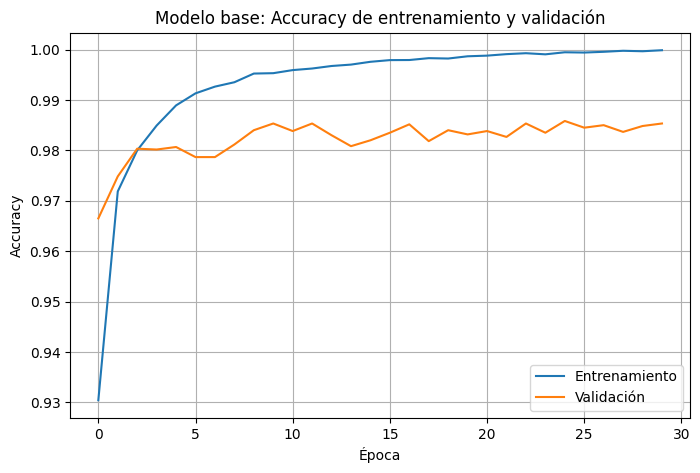

In [ ]:
# GRAFICA DEL MODELO BASE

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_best.history["accuracy"], label="Entrenamiento")
plt.plot(history_best.history["val_accuracy"], label="Validación")

plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("Modelo base: Accuracy de entrenamiento y validación")
plt.legend()
plt.grid(True)

plt.show()

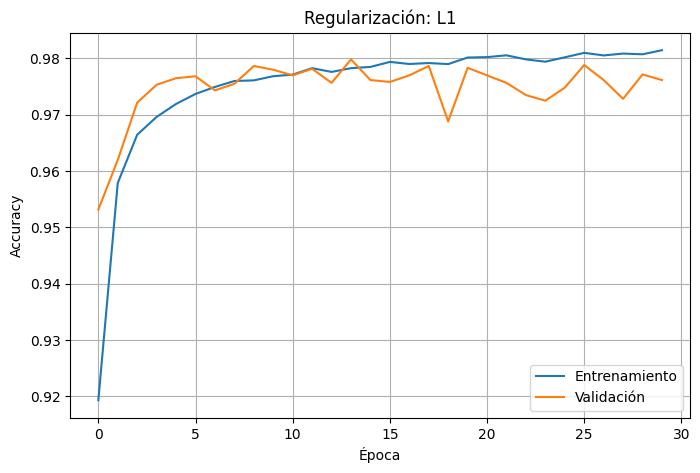

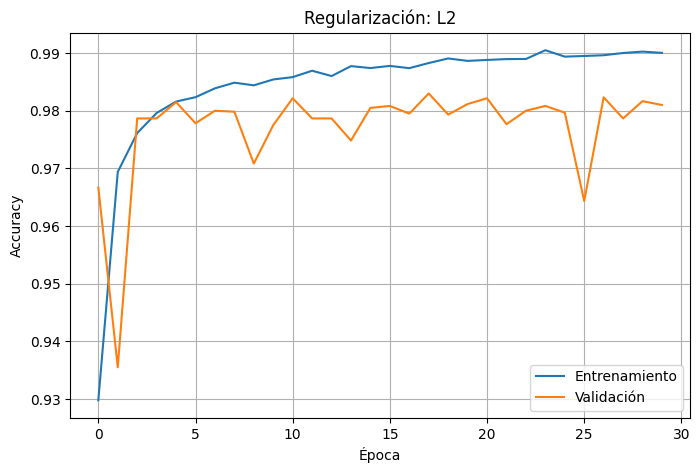

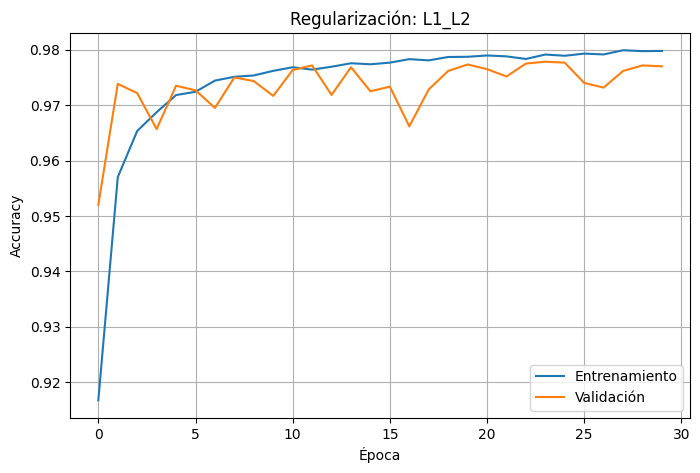

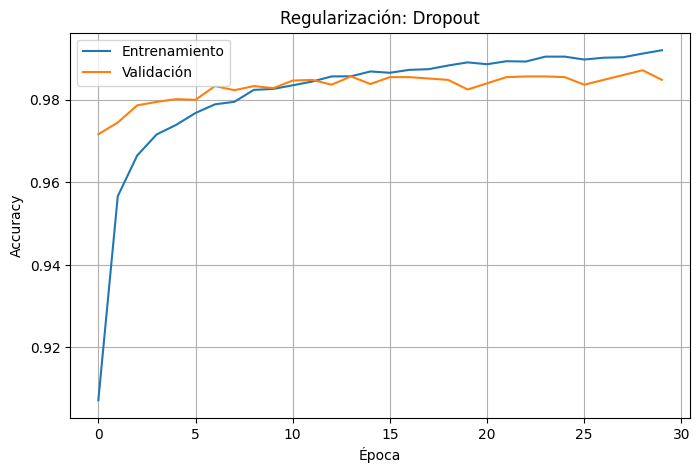

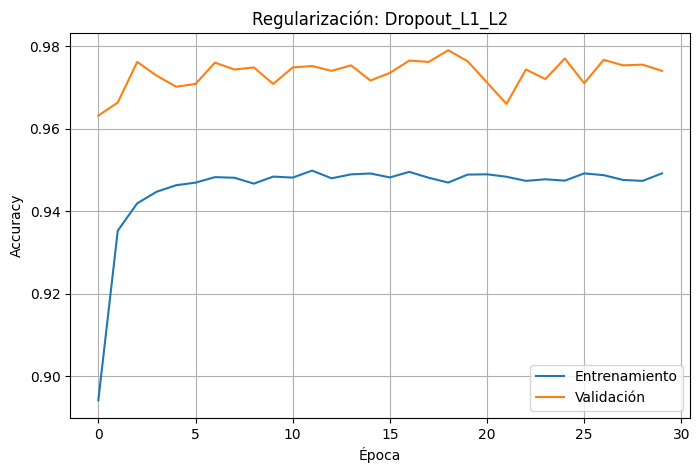

In [ ]:
# GRAFICA DE LAS REGULARIZACIONES

for tipo, history in historias_reg.items():

    plt.figure(figsize=(8,5))

    plt.plot(history.history["accuracy"], label="Entrenamiento")
    plt.plot(history.history["val_accuracy"], label="Validación")

    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.title(f"Regularización: {tipo}")
    plt.legend()
    plt.grid(True)

    plt.show()